In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import shap
import joblib
import warnings
import os

warnings.filterwarnings("ignore")

# This line is required for SHAP plots to render inside VS Code notebooks
shap.initjs()

print("All imports successful!")

All imports successful!


In [3]:
final_model=joblib.load("../data/processed/final_model.pkl")



X_train = joblib.load("../data/processed/X_train.pkl")
y_train = joblib.load("../data/processed/y_train.pkl")
X_val   = joblib.load("../data/processed/X_val.pkl")
y_val   = joblib.load("../data/processed/y_val.pkl")
X_test  = joblib.load("../data/processed/X_test.pkl")
y_test  = joblib.load("../data/processed/y_test.pkl")

print("Loaded successfully!")
print()
print(f"MODEL TYPE   : {type(final_model).__name__}")
print(f"VAL SHAPE    : {X_val.shape}")
print()
print("FEATURES      : list(X_val.columns)")

Loaded successfully!

MODEL TYPE   : XGBClassifier
VAL SHAPE    : (40215, 31)

FEATURES      : list(X_val.columns)


SHAAP EXPLAINER

In [4]:
print("CREATING SHAP TREEEXXPLAINER")

explainer=shap.TreeExplainer(final_model)
print("EXPLAINER CREATED")
print()

print("COMPUTING SHAP VALUES FOR 2000 VALIDATION SAMPLES...")
sample_size=2000
X_val_sample=X_val.sample(n=sample_size,random_state=42)
shap_values=explainer.shap_values(X_val_sample)

if isinstance(shap_values,list):
    shap_fraud=shap_values[1]
else:
    shap_fraud=shap_values
print(f"SHAP VALUES SHAPE: {shap_fraud.shape}")
print(f"DONE! EACH ROE = ONE TRANSACTION, EACH COLUMN=ONE FEATURES CONTRIBUTION")

CREATING SHAP TREEEXXPLAINER
EXPLAINER CREATED

COMPUTING SHAP VALUES FOR 2000 VALIDATION SAMPLES...
SHAP VALUES SHAPE: (2000, 31)
DONE! EACH ROE = ONE TRANSACTION, EACH COLUMN=ONE FEATURES CONTRIBUTION


SUMMARY PLOT - GLOBAL IMPORTANCE

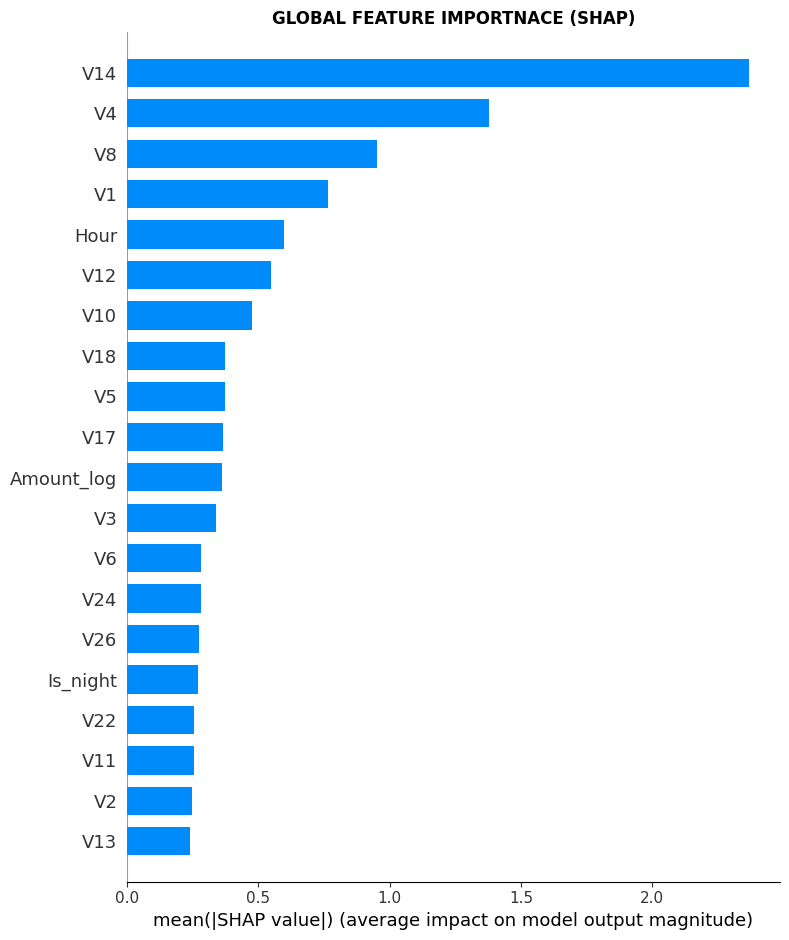

PLOT SAVED


In [5]:
plt.figure()
shap.summary_plot(
    shap_fraud,
    X_val_sample,
    plot_type="bar",
    show=False
)
plt.title("GLOBAL FEATURE IMPORTNACE (SHAP)",fontweight="bold")
plt.tight_layout()
plt.savefig("../data/processed/11_shap_gloabal_importance.png",dpi=150,bbox_inches="tight")
plt.show()
print("PLOT SAVED")

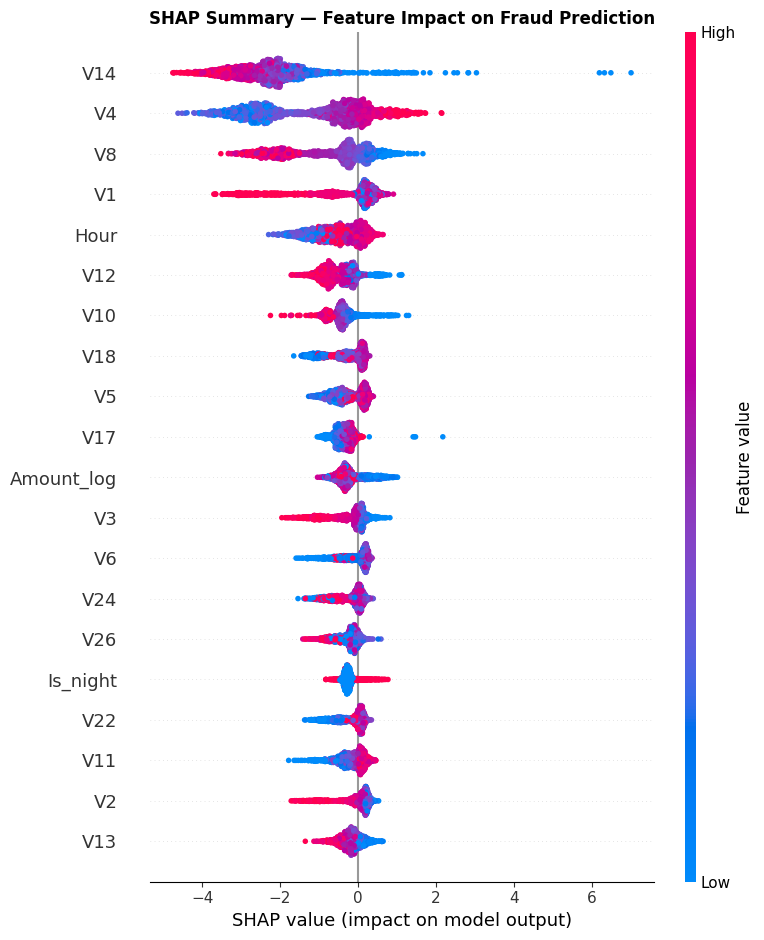

Plot saved!


In [6]:
# Dot version — shows direction AND magnitude
# Red dot = high feature value pushes toward fraud
# Blue dot = low feature value pushes toward fraud

plt.figure()
shap.summary_plot(
    shap_fraud,
    X_val_sample,
    show = False
)
plt.title("SHAP Summary — Feature Impact on Fraud Prediction", fontweight="bold")
plt.tight_layout()
plt.savefig("../data/processed/12_shap_summary_dot.png",
            dpi=150, bbox_inches="tight")
plt.show()
print("Plot saved!")

In [9]:
fraud_indices=y_val[y_val==1].index
print(f"FRAUD TRANSACTIONS IN VAL SET: {len(fraud_indices)}")

fraud_idx=fraud_indices[0]
fraud_row=X_val.loc[[fraud_idx]]

shap_single=explainer(fraud_row)

print(f"\nTRANSACTION INDEX  : {fraud_idx}")
print(f"MODEL PREDICTION     : {final_model.predict_proba(fraud_row)[0][1]*100:.2f}% fraud probability")
print(f"ACTUAL LABEL         : {'FRAUD' if y_val.loc[fraud_idx]==1 else 'LEGIT'}")

FRAUD TRANSACTIONS IN VAL SET: 70

TRANSACTION INDEX  : 44270
MODEL PREDICTION     : 99.99% fraud probability
ACTUAL LABEL         : FRAUD


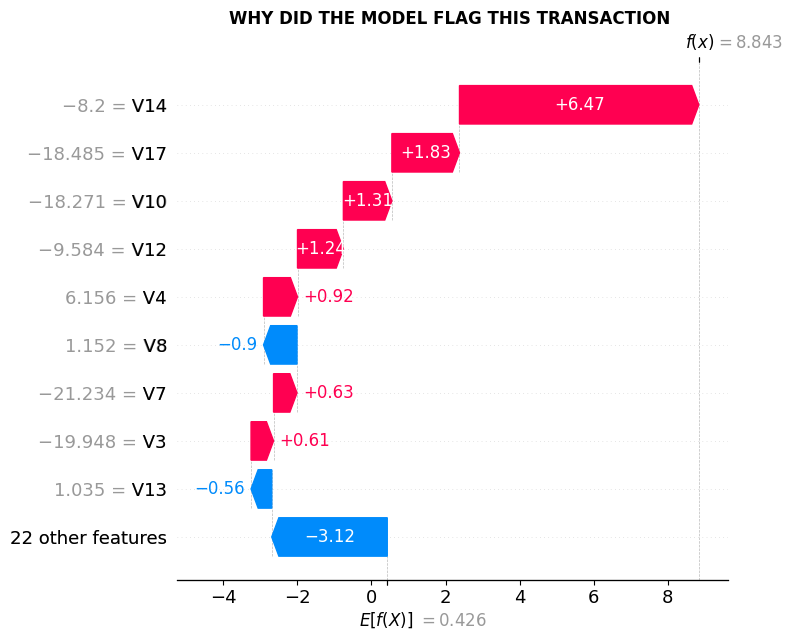

WATERFALL PLOT SAVED!


In [11]:
plt.figure()
shap.plots.waterfall(shap_single[0],show=False)
plt.title("WHY DID THE MODEL FLAG THIS TRANSACTION ",fontweight="bold")
plt.tight_layout()
plt.savefig("../data/processed/13_shap_waterfall_fraud.png",dpi=15,bbox_inches="tight")
plt.show()
print("WATERFALL PLOT SAVED!")

WATERFALL FOR LEGIT TRANSACTION

TRANSACTION INDEX     : 14682
MODEL PREDICTION      : 0.0013% fraud pprobability
ACTUAL LABEL          : LEGIT


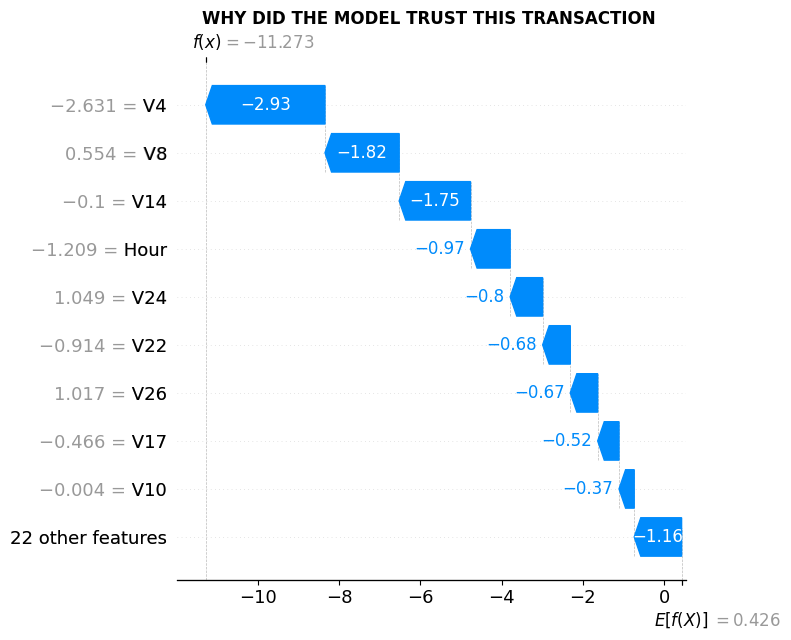

WATERFALL PLOT SAVED


In [14]:
legit_indices=y_val[y_val==0].index
legit_idx=legit_indices[0]
legit_row=X_val.loc[[legit_idx]]

shap_legit=explainer(legit_row)

print(f"TRANSACTION INDEX     : {legit_idx}")
print(f"MODEL PREDICTION      : {final_model.predict_proba(legit_row)[0][1]*100:.4f}% fraud pprobability")
print(f"ACTUAL LABEL          : LEGIT")

plt.figure()
shap.plots.waterfall(shap_legit[0],show=False)
plt.title("WHY DID THE MODEL TRUST THIS TRANSACTION ",fontweight="bold")
plt.tight_layout()
plt.savefig("../data/processed/14_shap_waterfall_legit.png",dpi=150,bbox_inches="tight")
plt.show()
print("WATERFALL PLOT SAVED")

FORCE PLOT

In [16]:
shap_exp=explainer(X_val_sample)

print("FORCE PLOT FOR THE FRAUD TRANSACTION: ")


force_plot=shap.force_plot(
    explainer.expected_value[1] if isinstance(explainer.expected_value,list)
    else explainer.expected_value,
    shap_fraud[0],
    X_val_sample.iloc[0],
    show=False
)
shap.save_html(
    "../data/processed/15_shap_force_plot.html",
    force_plot
)
print("Interactive force plot saved as HTML!")
print("Open data/processed/15_shap_force_plot.html in your browser to see it")

FORCE PLOT FOR THE FRAUD TRANSACTION: 
Interactive force plot saved as HTML!
Open data/processed/15_shap_force_plot.html in your browser to see it


DEPENDENCY PLOT

CREATING DEPENDENCE PLOT FOR TOP FETAURE: V14


<Figure size 800x500 with 0 Axes>

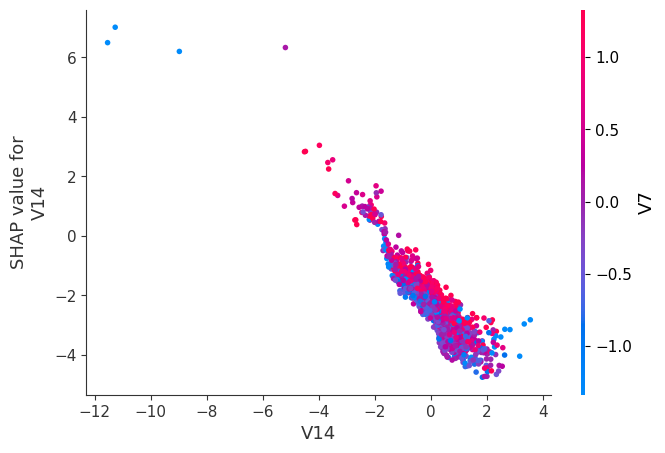

<Figure size 800x500 with 0 Axes>

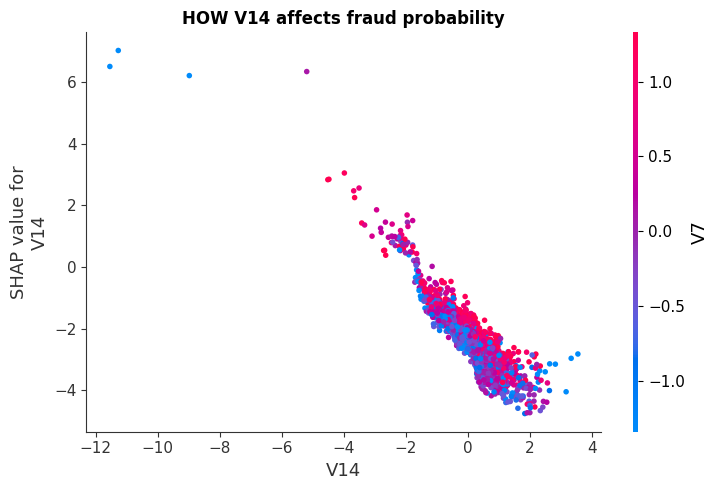

DEPENDENCE PLOT SAVED


In [18]:
top_feature=X_val_sample.columns[np.abs(shap_fraud).mean(axis=0).argmax()]
print(f"CREATING DEPENDENCE PLOT FOR TOP FETAURE: {top_feature}")

plt.figure(figsize=(8,5))
shap.dependence_plot(
    top_feature,
    shap_fraud,
    X_val_sample,
    show=False

)
plt.title(f"HOW {top_feature} affects fraud probability",fontweight="bold")
plt.tight_layout()
plt.savefig("../data/processed/16_shap_dependence.png",dpi=150,bbox_inches="tight")
plt.show()
print("DEPENDENCE PLOT SAVED")


EXPLAIN FUNNCTION"

In [26]:
def explain_prediction(transaction_row,model,explainer,top_n=5):
    fraud_prob=model.predict_proba(transaction_row)[0,1]
    verdict="FRAUD" if fraud_prob>=0.5 else "LEGIT"

    shap_vals=explainer.shap_values(transaction_row)
    if isinstance(shap_vals,list):
        shap_vals=shap_vals[1]

    explanation=pd.DataFrame({
        "feature"        : transaction_row.columns,
        "value"          : transaction_row.values[0],
        "shap_value"     : shap_vals[0],
        "direction"      : ["TOWARD FRAUD" if s > 0 else "AWAY FROM FRAUD" 
                                for s in shap_vals[0]]

    })
    explanation["abs_shap"]=explanation["shap_value"].abs()
    explanation=explanation.sort_values("abs_shap",ascending=False)

    top_reasons=explanation.head(top_n)[
        ["feature","value","shap_value","direction"]
    ].to_dict(orient="records")
    return{
        "fraud_probability"    : round(float(fraud_prob),4),
        "verdict"              : verdict,
        "confidence"           : "HIGH" if abs(fraud_prob - 0.5) > 0.3 else "LOW",
        "top_reasons"          : top_reasons
    }
print("EXPLAIN PREDICTION READY!")
    

EXPLAIN PREDICTION READY!


TESTING THE EXPLAIN FUNCTION

In [27]:
print("="*55)
print("TEST 1- FRAUD TRANSACTION")
print("="*55)

fraud_row=X_val.loc[[fraud_indices[0]]]
result=explain_prediction(fraud_row,final_model,explainer)

print(f"FRAUD PROBABILITY    : {result['fraud_probability']*100:.2f}%")
print(f"VERDICT              : {result['verdict']}")
print(f"Confidence        : {result['confidence']}")
print(f"\nTOP {len(result['top_reasons'])} reasons: ")
for i,reason in enumerate(result["top_reasons"],1):
    direction_arrow= "▲ toward fraud" if reason["shap_value"] > 0 else "▼ away from fraud"
    print(f"{i}.{reason['feature']:15s}={reason['value']:8.4f}"  
          f"| SHAP: {reason['shap_value']:+.4f} ({direction_arrow})")

    

TEST 1- FRAUD TRANSACTION
FRAUD PROBABILITY    : 99.99%
VERDICT              : FRAUD
Confidence        : HIGH

TOP 5 reasons: 
1.V14            = -8.1997| SHAP: +6.4657 (▲ toward fraud)
2.V17            =-18.4855| SHAP: +1.8267 (▲ toward fraud)
3.V10            =-18.2712| SHAP: +1.3108 (▲ toward fraud)
4.V12            = -9.5836| SHAP: +1.2388 (▲ toward fraud)
5.V4             =  6.1558| SHAP: +0.9179 (▲ toward fraud)


TESTING LEGIT TRANSCTION

In [30]:
print("="*55)
print("TEST 2- LEGIT TRANSACTION")
print("="*55)
legit_row=X_val[y_val == 0].iloc[[0]]

result_legit=explain_prediction(
    legit_row,
    final_model,
    explainer
)

print(f"FRAUD PROBABILITY  :{result_legit['fraud_probability']*100:.2f}%")
print(f"VERDICT            :{result_legit['verdict']}")
print(f"CONFIDENCE         :{result_legit['confidence']}")

print(f"\n TOP {len(result_legit['top_reasons'])}reasons:")

for i,reason in enumerate(result_legit['top_reasons'],1):
    direction_arrow=(
        "▲ toward fraud"
        if reason["shap_value"] > 0
        else "▼ away from fraud"
    )
    print(
        f"{i}.{reason['feature']:15s}"
        f"={reason['value']:8.4f}"
        f"| SHAP: {reason['shap_value']:+.4f}"
        f"({direction_arrow})"
    ) 

TEST 2- LEGIT TRANSACTION
FRAUD PROBABILITY  :0.00%
VERDICT            :LEGIT
CONFIDENCE         :HIGH

 TOP 5reasons:
1.V4             = -2.6311| SHAP: -2.9316(▼ away from fraud)
2.V8             =  0.5544| SHAP: -1.8242(▼ away from fraud)
3.V14            = -0.1001| SHAP: -1.7535(▼ away from fraud)
4.Hour           = -1.2095| SHAP: -0.9749(▼ away from fraud)
5.V24            =  1.0495| SHAP: -0.7988(▼ away from fraud)


In [31]:
# Save explainer for use in the API on Day 5
joblib.dump(explainer, "../data/processed/shap_explainer.pkl")

print("Saved:")
print("  shap_explainer.pkl")
print()
print("Files in data/processed:")
for f in sorted(os.listdir("../data/processed")):
    size = os.path.getsize(f"../data/processed/{f}") / 1e6
    print(f"  {f:45s} {size:.1f} MB")

Saved:
  shap_explainer.pkl

Files in data/processed:
  01_classdistribution.png                      0.1 MB
  02_transaction_amount.png                     0.0 MB
  03_temporal_patterns.png                      0.2 MB
  04_feature_correlation.png                    0.0 MB
  05_smote_effect.png                           0.0 MB
  07_roc_curves.png                             0.1 MB
  08_pr_curves.png                              0.0 MB
  10_featrure_imortance.png                     0.0 MB
  11_shap_gloabal_importance.png                0.1 MB
  12_shap_summary_dot.png                       0.2 MB
  13_shap_waterfall_fraud.png                   0.0 MB
  14_shap_waterfall_legit.png                   0.1 MB
  15_shap_force_plot.html                       0.4 MB
  16_shap_dependence.png                        0.1 MB
  X_test.pkl                                    14.6 MB
  X_train.pkl                                   92.9 MB
  X_val.pkl                                     10.3 MB
  best_p

In [34]:
import numpy as np
from sklearn.metrics import f1_score

print("Recomputing best threshold...")

y_prob = final_model.predict_proba(X_val)[:,1]

thresholds = np.arange(0.1,0.95,0.05)

best_f1 = 0
best_threshold = 0.5

for t in thresholds:

    y_pred_t = (y_prob >= t).astype(int)

    f1 = f1_score(y_val, y_pred_t)

    if f1 > best_f1:
        best_f1 = f1
        best_threshold = t

print(f"BEST THRESHOLD : {best_threshold}")
print(f"BEST F1        : {best_f1:.4f}")

Recomputing best threshold...
BEST THRESHOLD : 0.9000000000000002
BEST F1        : 0.8175


In [35]:
import joblib

print("Saving deployment artifacts...")

# Save model
joblib.dump(
    final_model,
    "../data/processed/final_model.pkl"
)

# Save threshold
joblib.dump(
    best_threshold,
    "../data/processed/best_threshold.pkl"
)

# Save feature names
joblib.dump(
    list(X_train.columns),
    "../data/processed/feature_names.pkl"
)

print("Saved:")
print("  final_model.pkl")
print("  best_threshold.pkl")
print("  feature_names.pkl")
print("  shap_explainer.pkl")

Saving deployment artifacts...
Saved:
  final_model.pkl
  best_threshold.pkl
  feature_names.pkl
  shap_explainer.pkl


In [36]:
import os

print("Files in data/processed:\n")

for f in sorted(os.listdir("../data/processed")):
    size = os.path.getsize(f"../data/processed/{f}") / 1e6
    print(f"{f:45s} {size:.1f} MB")
    

Files in data/processed:

01_classdistribution.png                      0.1 MB
02_transaction_amount.png                     0.0 MB
03_temporal_patterns.png                      0.2 MB
04_feature_correlation.png                    0.0 MB
05_smote_effect.png                           0.0 MB
07_roc_curves.png                             0.1 MB
08_pr_curves.png                              0.0 MB
10_featrure_imortance.png                     0.0 MB
11_shap_gloabal_importance.png                0.1 MB
12_shap_summary_dot.png                       0.2 MB
13_shap_waterfall_fraud.png                   0.0 MB
14_shap_waterfall_legit.png                   0.1 MB
15_shap_force_plot.html                       0.4 MB
16_shap_dependence.png                        0.1 MB
X_test.pkl                                    14.6 MB
X_train.pkl                                   92.9 MB
X_val.pkl                                     10.3 MB
best_params.pkl                               0.0 MB
best_threshold.pk

## Explainability Summary 

**SHAP Global Importance — top 3 features:**
1. ___ — (high/low value pushes toward fraud)
2. ___ — (high/low value pushes toward fraud)
3. ___

**Single fraud transaction explained:**
- Fraud probability : ___%
- Top reason it was flagged : ___

**Single legit transaction:**
- Fraud probability : ___%
- Top reason it was trusted : ___

**Why SHAP matters in interviews:**
- It proves the model isn't a black box
- Shows you understand feature contributions
- Regulators (RBI, banks) require explainability
- Builds trust in model decisions


In [ ]:
import shutil
import os

os.makedirs("models", exist_ok=True)

files = [
    "final_model.pkl",
    "best_threshold.pkl",
    "feature_names.pkl",
    "shap_explainer.pkl"
]

for f in files:s
    shutil.copy(
        f"data/processed/{f}",
        f"models/{f}"
    )

print("✅ Model files copied successfully!")

In [ ]:
import os

print(os.listdir("models"))